# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
# Desenvolva aqui o DESAFIO 1

In [7]:
# 1. Criar o DataFrame
dados = pd.DataFrame(registros)

In [8]:
# 2. Primeiros registros
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [9]:
dados.shape

(336, 11)

In [10]:
# 3. Quantidade de linhas e colunas
print("Linhas:", dados.shape[0])
print("Colunas:", dados.shape[1])

Linhas: 336
Colunas: 11


In [11]:
# 4. Nomes dos atributos
print(dados.columns)

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')


In [12]:
# 5. Informações do DataFrame
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [13]:
# 6. Estatísticas descritivas
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [14]:
# Desenvolva aqui o DESAFIO 2

In [15]:
#1 Renomear os principais atributos
dados = dados.rename(columns={
    'cod_areacarga': 'area_carga',
    'dat_referencia': 'data',
    'din_referenciautc': 'hora',
    'val_cargaglobal': 'carga'
})

In [16]:
#2 Criar um novo DataFrame apenas com os atributos necessários
df = dados[['area_carga', 'data', 'hora', 'carga']]

df.head()

,area_carga,data,hora,carga
0,SP,2025-08-01,2025-08-01T03:30:00.000Z,15913.618
1,SP,2025-08-01,2025-08-01T04:00:00.000Z,15251.414
2,SP,2025-08-01,2025-08-01T04:30:00.000Z,14606.733
3,SP,2025-08-01,2025-08-01T05:00:00.000Z,14182.290
4,SP,2025-08-01,2025-08-01T05:30:00.000Z,13838.488


In [17]:
#3 Verificar valores ausentes
print("\nValores ausentes:")
print(df.isnull().sum())


Valores ausentes:
area_carga    0
data          0
hora          0
carga         0
dtype: int64


In [18]:
#4 Informar quantos valores ausentes há em cada atributo relevante
ausentes = df.isnull().sum()

print("Valores ausentes por atributo:")
print(ausentes)

Valores ausentes por atributo:
area_carga    0
data          0
hora          0
carga         0
dtype: int64


In [19]:
#5 Verificar se a variável de carga está em formato numérico
df['carga'].dtype

dtype('float64')

In [20]:
#6 Verificar como a data/hora está representada
print(df["data"].dtype)
print(df["hora"].dtype)
print(df[["data", "hora"]].head())

object
object
         data                      hora
0  2025-08-01  2025-08-01T03:30:00.000Z
1  2025-08-01  2025-08-01T04:00:00.000Z
2  2025-08-01  2025-08-01T04:30:00.000Z
3  2025-08-01  2025-08-01T05:00:00.000Z
4  2025-08-01  2025-08-01T05:30:00.000Z


### 7. Decisões de tratamento

Não foram encontrados valores ausentes nos atributos selecionados.

A variável `carga` já está em formato numérico (`float64`), portanto não foi necessário realizar conversão.

As variáveis `data` e `hora` estão representadas como `object`, ou seja, como texto. Por isso, será necessário convertê-las para formato de data/hora antes de análises temporais.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [21]:
# Desenvolva aqui o DESAFIO 3

In [22]:
#1 Calcular a carga mínima
carga_minima = df["carga"].min()
print("Carga mínima:", carga_minima)

Carga mínima: 12139.253


In [23]:
#2 Calcular a carga máxima
carga_maxima = df["carga"].max()
print("Carga máxima:", carga_maxima)

Carga máxima: 23185.312


In [24]:
#3 Calcular a carga média
carga_media = df["carga"].mean()
print("Carga média:", carga_media)

Carga média: 17870.828980654762


In [25]:
#4 Calcular a mediana
mediana = df["carga"].median()
print("Mediana:", mediana)

Mediana: 18199.1285


In [26]:
#5 Calcular a amplitude
amplitude = carga_maxima - carga_minima
print("Amplitude:", amplitude)

Amplitude: 11046.059000000001


In [27]:
#6 Calcular a quantidade total de medições
total_medicoes = df["carga"].count()
print("Quantidade total de medições:", total_medicoes)

Quantidade total de medições: 336


### Análise dos indicadores

O valor máximo está acima da média, mas não parece extremamente distante do comportamento observado. A carga máxima foi de 23.185,312, enquanto a média foi de aproximadamente 17.870,829. A mediana, de 18.199,1285, também ficou próxima da média, indicando que os valores estão relativamente concentrados em torno dessa faixa.

A amplitude entre o maior e o menor valor foi de 11.046,059, mostrando que existe uma variação considerável entre as 336 medições.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [28]:
#1 Desenvolva aqui o DESAFIO 4

In [29]:
#2 Calcule o limiar
limiar = carga_maxima * 0.9
print(f"Limiar: {limiar:.2f}")

Limiar: 20866.78


In [30]:
#3 Crie um novo DataFrame com os registros acima dele
df_alta_demanda = df[df["carga"] > limiar]
df_alta_demanda.head()

,area_carga,data,hora,carga
35,SP,2025-08-01,2025-08-01T21:00:00.000Z,21088.959
36,SP,2025-08-01,2025-08-01T21:30:00.000Z,22398.360
37,SP,2025-08-01,2025-08-01T22:00:00.000Z,23185.312
38,SP,2025-08-01,2025-08-01T22:30:00.000Z,22903.314
39,SP,2025-08-01,2025-08-01T23:00:00.000Z,22358.701


In [31]:
#4 Conte os registros
quantidade_registros = df_alta_demanda.shape[0]
print("Quantidade de registros:", quantidade_registros)

Quantidade de registros: 50


In [32]:
#5 Calcule o percentual em relação ao total
percentual = (quantidade_registros / total_medicoes) * 100
print(f"Percentual: {percentual:.2f}%")

Percentual: 14.88%


In [33]:
#6 Identifique a data e o horário do pico, quando disponíveis
pico = df_alta_demanda["carga"].idxmax()
data_pico = df.loc[pico, "data"]
hora_pico = df.loc[pico, "hora"]
print(f"Data do pico: {data_pico}")
print(f"Hora do pico: {hora_pico}")

Data do pico: 2025-08-01
Hora do pico: 2025-08-01T22:00:00.000Z


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [34]:
# Desenvolva aqui o DESAFIO 5

In [35]:
#1 Carga acima da média
print("1. Critério escolhido: Carga acima da média")

#2 Crie um novo DataFrame com os registros acima da média
df_acima_media = df[df["carga"] > carga_media]
print("\n2. Novo DataFrame (primeiros 5 registros):")
print("\n", df_acima_media.head())

#3 Conte os registros
quantidade_registros_media = df_acima_media.shape[0]
print(f"\n3. Quantidade de registros (acima da média): {quantidade_registros_media}")

#4 Calcule o percentual em relação ao total
percentual_media = (quantidade_registros_media / total_medicoes) * 100
print(f"\n4. Percentual de registros (acima da média): {percentual_media:.2f}%")

#5 Comparação com o conjunto de alta demanda
print("\n5. Comparação com o conjunto de alta demanda:")
print(f"  - Registros de alta demanda (90% do máximo): {quantidade_registros}")
print(f"  - Percentual de alta demanda: {percentual:.2f}%")
print(f"  - Registros acima da média: {quantidade_registros_media}")
print(f"  - Percentual acima da média: {percentual_media:.2f}%")



1. Critério escolhido: Carga acima da média

2. Novo DataFrame (primeiros 5 registros):

    area_carga        data                      hora      carga
15         SP  2025-08-01  2025-08-01T11:00:00.000Z  18096.023
16         SP  2025-08-01  2025-08-01T11:30:00.000Z  18629.395
17         SP  2025-08-01  2025-08-01T12:00:00.000Z  18825.176
18         SP  2025-08-01  2025-08-01T12:30:00.000Z  19056.504
19         SP  2025-08-01  2025-08-01T13:00:00.000Z  19427.822

3. Quantidade de registros (acima da média): 184

4. Percentual de registros (acima da média): 54.76%

5. Comparação com o conjunto de alta demanda:
  - Registros de alta demanda (90% do máximo): 50
  - Percentual de alta demanda: 14.88%
  - Registros acima da média: 184
  - Percentual acima da média: 54.76%


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

/tmp/ipykernel_658/2846460323.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["datetime"] = pd.to_datetime(df["hora"], utc=True)


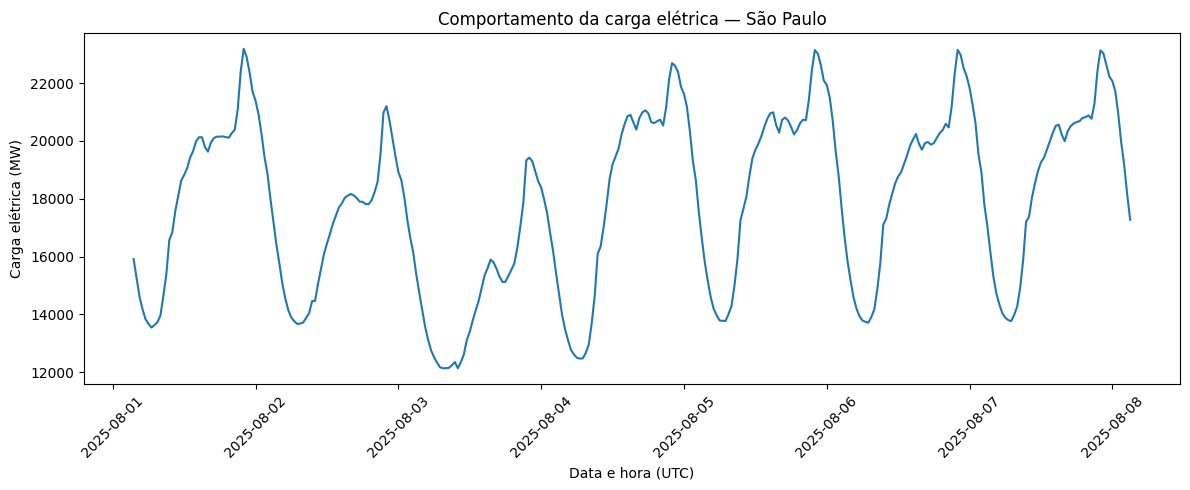

Interpretação: O gráfico mostra a variação da carga elétrica ao longo do período analisado, permitindo observar os momentos de maior e menor demanda e as oscilações entre as medições.


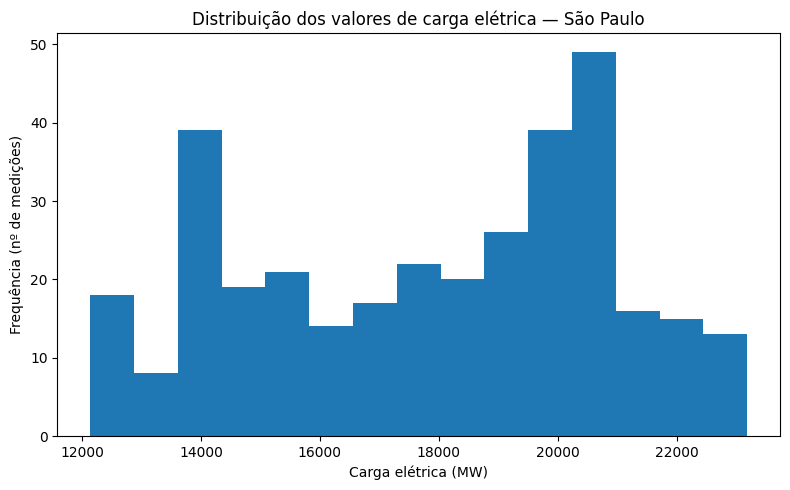

Interpretação: O histograma mostra como as 336 medições se distribuem pelos diferentes níveis de carga, permitindo visualizar em quais faixas os valores se concentram.


In [36]:
# DESAFIO 6 — Visualização

# Criar uma variável de data/hora para ordenar e representar as observações no tempo.
df["datetime"] = pd.to_datetime(df["hora"], utc=True)

# Ordenar os dados cronologicamente.
df_plot = df.sort_values("datetime")

# Gráfico 1 — comportamento da carga ao longo do período
plt.figure(figsize=(12, 5))
plt.plot(df_plot["datetime"], df_plot["carga"])
plt.title("Comportamento da carga elétrica — São Paulo")
plt.xlabel("Data e hora (UTC)")
plt.ylabel("Carga elétrica (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretação: O gráfico mostra a variação da carga elétrica ao longo do período analisado, permitindo observar os momentos de maior e menor demanda e as oscilações entre as medições.")

# Gráfico 2 — distribuição das cargas
plt.figure(figsize=(8, 5))
plt.hist(df["carga"], bins=15)
plt.title("Distribuição dos valores de carga elétrica — São Paulo")
plt.xlabel("Carga elétrica (MW)")
plt.ylabel("Frequência (nº de medições)")
plt.tight_layout()
plt.show()

print("Interpretação: O histograma mostra como as 336 medições se distribuem pelos diferentes níveis de carga, permitindo visualizar em quais faixas os valores se concentram.")


## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [37]:
# Exemplo de estrutura:
#
# resumo_resultados = f'''
# Região analisada: ...
# Período analisado: ...
# Quantidade de registros: ...
# Carga mínima: ...
# Carga máxima: ...
# Carga média: ...
# Mediana: ...
# Limiar de alta demanda: ...
# Registros de alta demanda: ...
# Percentual de alta demanda: ...
# Momento do pico: ...
# Segundo critério: ...
# '''
#
# print(resumo_resultados)

In [38]:
# DESAFIO 7 — Síntese para o relatório

# Garantir que a data/hora esteja em formato adequado para identificar o pico.
df["datetime"] = pd.to_datetime(df["hora"], utc=True)

# Indicadores principais
regiao = df["area_carga"].iloc[0]
periodo_inicio = df["datetime"].min()
periodo_fim = df["datetime"].max()

carga_minima = df["carga"].min()
carga_maxima = df["carga"].max()
carga_media = df["carga"].mean()
mediana = df["carga"].median()
total_medicoes = len(df)

# Alta demanda: acima de 90% da carga máxima
limiar_alta = 0.90 * carga_maxima
alta_demanda = df[df["carga"] > limiar_alta]
qtd_alta = len(alta_demanda)
perc_alta = (qtd_alta / total_medicoes) * 100

# Momento do pico
indice_pico = df["carga"].idxmax()
momento_pico = df.loc[indice_pico, "datetime"]
valor_pico = df.loc[indice_pico, "carga"]

# Segundo critério: carga acima da média
acima_media = df[df["carga"] > carga_media]
qtd_acima_media = len(acima_media)
perc_acima_media = (qtd_acima_media / total_medicoes) * 100

# Variável solicitada no enunciado
resumo_resultados = f'''
Região analisada: {regiao}
Período analisado: {periodo_inicio.strftime("%d/%m/%Y %H:%M")} a {periodo_fim.strftime("%d/%m/%Y %H:%M")} (UTC)
Quantidade de registros: {total_medicoes}

Carga mínima: {carga_minima:.3f} MW
Carga máxima: {carga_maxima:.3f} MW
Carga média: {carga_media:.3f} MW
Mediana: {mediana:.3f} MW

Limiar de alta demanda (90% do máximo): {limiar_alta:.3f} MW
Registros de alta demanda: {qtd_alta}
Percentual de alta demanda: {perc_alta:.2f}%

Momento do pico: {momento_pico.strftime("%d/%m/%Y %H:%M")} (UTC)
Valor do pico: {valor_pico:.3f} MW

Segundo critério: carga acima da média ({carga_media:.3f} MW)
Registros acima da média: {qtd_acima_media}
Percentual acima da média: {perc_acima_media:.2f}%
'''

print(resumo_resultados)



Região analisada: SP
Período analisado: 01/08/2025 03:30 a 08/08/2025 03:00 (UTC)
Quantidade de registros: 336

Carga mínima: 12139.253 MW
Carga máxima: 23185.312 MW
Carga média: 17870.829 MW
Mediana: 18199.128 MW

Limiar de alta demanda (90% do máximo): 20866.781 MW
Registros de alta demanda: 50
Percentual de alta demanda: 14.88%

Momento do pico: 01/08/2025 22:00 (UTC)
Valor do pico: 23185.312 MW

Segundo critério: carga acima da média (17870.829 MW)
Registros acima da média: 184
Percentual acima da média: 54.76%



/tmp/ipykernel_658/135291235.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["datetime"] = pd.to_datetime(df["hora"], utc=True)


# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [41]:
!pip -q install -U google-genai

In [42]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [43]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [45]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE CARGA ELÉTRICA – REGIÃO SP**

---

### 1. Caracterização do conjunto analisado
O presente relatório analisa o comportamento da demanda de carga elétrica na região de **São Paulo (SP)**.
* **Período de amostragem:** De 01/08/2025 às 03:30 a 08/08/2025 às 03:00 (horário UTC).
* **Volume de dados:** 336 registros temporais continuados.

---

### 2. Principais indicadores
A análise estatística descritiva dos 336 registros apresentou os seguintes valores fundamentais:

* **Carga Mínima:** 12.139,253 MW
* **Carga Máxima (Pico):** 23.185,312 MW
* **Carga Média:** 17.870,829 MW
* **Mediana:** 18.199,128 MW

*Resultado observado:* A mediana apresentou valor ligeiramente superior à média (diferença de 328,299 MW), indicando que em mais da metade do período a demanda se manteve em patamares superiores à média aritmética calculada.

---

### 3. Análise dos períodos de alta demanda
O critério de alta demanda foi estabelecido no limiar de 90% do valor máximo registr

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

Relatório Técnico — Análise da Carga Elétrica em São Paulo -  DESAFIO 8



**Caracterização do conjunto analisado**



A análise foi realizada com dados de carga elétrica da área de carga de São Paulo (SP), referentes ao período de 01 a 07 de agosto de 2025. O conjunto contém 336 medições, realizadas em intervalos de 30 minutos, sem valores ausentes nas variáveis analisadas.



Os dados utilizados são provenientes da Carga Verificada do Operador Nacional do Sistema Elétrico (ONS).



**Principais indicadores**



Os principais indicadores calculados para as 336 medições foram:



| Indicador              |   Resultado |

| ---------------------- | ----------: |

| Quantidade de medições |         336 |

| Carga mínima           |  12.139,253 |

| Carga máxima           |  23.185,312 |

| Carga média            |  17.870,829 |

| Mediana                | 18.199,1285 |

| Amplitude              |  11.046,059 |



Os resultados mostram uma diferença significativa entre a menor e a maior carga registrada. A amplitude foi de 11.046,059, indicando variação relevante ao longo do período.



A média de 17.870,829 ficou próxima da mediana de 18.199,1285. Essa proximidade indica que os valores centrais do conjunto estão concentrados em uma faixa semelhante.



A carga máxima registrada foi de 23.185,312, enquanto a mínima foi de 12.139,253. Esses resultados estão diretamente de acordo com os indicadores calculados no notebook.



**Pico e períodos de alta demanda**



Para identificar os períodos de alta demanda, foi adotado o critério de considerar como alta demanda os registros superiores a 90% da carga máxima, conforme estabelecido no desafio.



Com carga máxima de 23.185,312, o limiar correspondente a 90% é de aproximadamente 20.866,781.



Nesse critério, foram identificados 50 registros de alta demanda, correspondentes a aproximadamente 14,9% das 336 medições.



O pico de carga foi de 23.185,312, registrado em 01/08/2025 às 22h00 (UTC).



Os períodos de alta demanda não ficaram restritos apenas ao instante do pico. Foram observados registros acima do limiar em diferentes momentos do conjunto, indicando que os valores próximos ao pico representam uma parcela menor do período total analisado, e não a maior parte das medições.



**Comparação entre os critérios**



O primeiro critério utilizado para caracterizar alta demanda foi:



Carga superior a 90% da carga máxima.



Esse critério resultou em 50 registros, ou aproximadamente 14,9% do total.



O desafio também determina a criação de um segundo recorte, que pode utilizar, por exemplo, carga acima da média, uma porcentagem do máximo, um intervalo de valores ou determinado período. O objetivo é comparar esse segundo conjunto com o conjunto de alta demanda.

No material analisado, entretanto, não há um resultado calculado para o segundo critério. Portanto, não é possível apresentar uma comparação numérica válida entre os dois critérios sem acrescentar um cálculo que não consta nos resultados registrados.



Essa ausência deve ser mantida explícita no relatório para evitar a criação de um resultado não produzido pela equipe.



**Observações**



Observações baseadas nos dados



\* Foram analisadas 336 medições.

\* A carga variou entre 12.139,253 e 23.185,312.

\* A diferença entre os extremos foi de 11.046,059.

\* A média foi de 17.870,829 e a mediana foi de 18.199,1285.

\* O maior valor registrado foi 23.185,312, às 22h00 UTC de 01/08/2025.

\* Considerando o limite de 90% da carga máxima, 50 medições foram classificadas como de alta demanda.

\* Essas 50 medições representam aproximadamente 14,9% do conjunto analisado.



**Hipóteses**



Os dados demonstram a existência de variações de carga e de períodos de maior demanda, mas não permitem determinar, isoladamente, as causas dessas variações.



Assim, não é possível afirmar, com base apenas neste conjunto, que os picos tenham sido provocados por fatores como temperatura, horário de trabalho, atividade industrial, comportamento residencial ou qualquer outro fator externo.



Como hipótese para análises futuras, os períodos de maior carga poderiam ser comparados com outras variáveis, como temperatura, dia da semana, condições climáticas e características do consumo. Entretanto, essa relação não pode ser considerada comprovada neste relatório.



**Conclusão**



A análise das 336 medições de carga elétrica de São Paulo entre 01 e 07 de agosto de 2025 mostra uma variação significativa da carga ao longo do período. A carga média foi de 17.870,829, enquanto o valor máximo atingiu 23.185,312 e o mínimo foi de 12.139,253.



O pico ocorreu em 01/08/2025 às 22h00 UTC. Pelo critério de alta demanda definido como valores superiores a 90% da carga máxima, foram identificadas 50 medições, equivalentes a aproximadamente 14,9% do período analisado. Dessa forma, os períodos de alta demanda representam uma parcela relativamente pequena do conjunto total.



A comparação com um segundo critério não pôde ser **concluída** porque o resultado desse recorte não foi registrado no material analisado. Portanto, a principal conclusão sustentada pelos dados é que os períodos classificados como alta demanda são pontuais em relação ao conjunto completo, embora apresentem valores significativamente superiores aos níveis mínimos observados.



Não foram atribuídas causas às variações porque os dados analisados não são suficientes para estabelecer relações causais.











Perguntas - Desafio 9



**1. Os indicadores foram utilizados corretamente?**



Sim, em geral. Foram utilizados os principais indicadores solicitados: quantidade de medições, carga mínima, máxima, média, mediana e amplitude. Os cálculos registrados no arquivo são coerentes entre si. Foram analisadas 336 medições, com carga mínima de 12.139,253, máxima de 23.185,312, média de 17.870,829 e mediana de 18.199,1285.



Além disso, o critério de alta demanda foi definido objetivamente como carga superior a 90% da carga máxima, conforme solicitado no desafio.



**2. Há alguma afirmação que não pode ser confirmada pelos dados?**



Sim. A afirmação de que os valores estão “relativamente concentrados” em torno da média é uma interpretação dos dados, mas não é demonstrada apenas pela proximidade entre média e mediana.



Também não é possível confirmar as causas dos picos ou das variações da carga, porque o conjunto analisado apresenta basicamente os valores de carga e seus horários, sem informações que permitam estabelecer uma causa.



**3. Houve interpretação exagerada ou causalidade não demonstrada?**



Não houve atribuição de uma causa específica, o que é positivo. O próprio relatório estabelece que não devem ser inventadas causas nem apresentadas explicações não sustentadas pelos dados.



Entretanto, a expressão “não parece extremamente distante do comportamento observado” pode ser considerada uma interpretação um pouco subjetiva. Seria melhor substituí-la por uma descrição objetiva dos números, como: “a carga máxima foi 23.185,312, enquanto a média foi 17.870,829”.



**4. Que alterações a equipe realizou no texto?**



A equipe realizou principalmente estas alterações:



Transformou os resultados numéricos em uma análise escrita, apresentando média, mediana, mínimo, máximo e amplitude.

Destacou o pico de carga e os períodos classificados como alta demanda.

Aplicou o critério de 90% da carga máxima para definir alta demanda.

Separou observações de hipóteses, evitando apresentar possíveis explicações como fatos.

Retirou ou evitou causas não comprovadas pelos dados, como temperatura, comportamento dos consumidores ou atividade industrial.

Incluiu uma ressalva sobre o segundo critério, pois o material disponível não apresentava seu resultado calculado. O desafio, porém, exige que esse segundo recorte seja apresentado e comparado com o conjunto de alta demanda.



**Em resumo:** os indicadores principais foram bem utilizados, mas algumas interpretações poderiam ser mais objetivas. A principal melhoria foi deixar claro o que os dados comprovam e o que seria apenas uma hipótese, evitando conclusões causais sem evidência.



---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**